In this notebook, we use CNN for classification of the MNIST dataset.

In [ ]:
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
from torchvision import datasets, transforms

In [ ]:
train_dataset = datasets.MNIST(root= "/content/data",
                      train= True,
                      download= True,
                      transform= transforms.ToTensor())

In [ ]:
test_dataset = datasets.MNIST(root= "/content/data",
                      train= False,
                      download= True,
                      transform= transforms.ToTensor())

In [ ]:
class ConvNeuralNetwork(nn.Module):
    def __init__(self):
        super().__init__()

        self.conv1 = nn.Conv2d(
            in_channels=1,
            out_channels=16,
            kernel_size=3,
            padding=1
        )

        self.relu1 = nn.ReLU()
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)

        self.conv2 = nn.Conv2d(
            in_channels=16,
            out_channels=32,
            kernel_size=3,
            padding=1
        )

        self.relu2 = nn.ReLU()
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)

        self.flatten = nn.Flatten()

        self.fc = nn.Linear(32 * 7 * 7, 10)

    def forward(self, x):
        x = self.conv1(x)
        x = self.relu1(x)
        x = self.pool1(x)

        x = self.conv2(x)
        x = self.relu2(x)
        x = self.pool2(x)

        x = self.flatten(x)
        x = self.fc(x)

        return x

In [ ]:
from torch.utils.data import DataLoader
train_loader = DataLoader(
    dataset,
    batch_size=64,
    shuffle=True
)

In [ ]:
model = ConvNeuralNetwork()

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

num_epochs = 5

for epoch in range(num_epochs):

    running_loss = 0.0

    for images, labels in train_loader:

        outputs = model(images)
        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    average_loss = running_loss / len(train_loader)

    print(
        f"Epoch {epoch+1}/{num_epochs}, "
        f"Loss: {average_loss:.4f}"
    )

Epoch 1/5, Loss: 0.2298
Epoch 2/5, Loss: 0.0692
Epoch 3/5, Loss: 0.0509
Epoch 4/5, Loss: 0.0424
Epoch 5/5, Loss: 0.0355


In [ ]:
test_loader = DataLoader(
    test_dataset,
    batch_size=64,
    shuffle=False
)

In [ ]:
model.eval()

correct = 0
total = 0

with torch.no_grad():
    for images, labels in test_loader:

        outputs = model(images)

        predictions = outputs.argmax(dim=1)

        total += labels.size(0)
        correct += (predictions == labels).sum().item()

accuracy = correct / total

print(f"Test accuracy: {accuracy * 100:.2f}%")

Test accuracy: 98.83%


In [ ]:
model.eval()

wrong_images = []
wrong_labels = []
wrong_predictions = []

with torch.no_grad():
    for images, labels in test_loader:
        outputs = model(images)
        predictions = outputs.argmax(dim=1)

        wrong = predictions != labels

        wrong_images.extend(images[wrong])
        wrong_labels.extend(labels[wrong])
        wrong_predictions.extend(predictions[wrong])

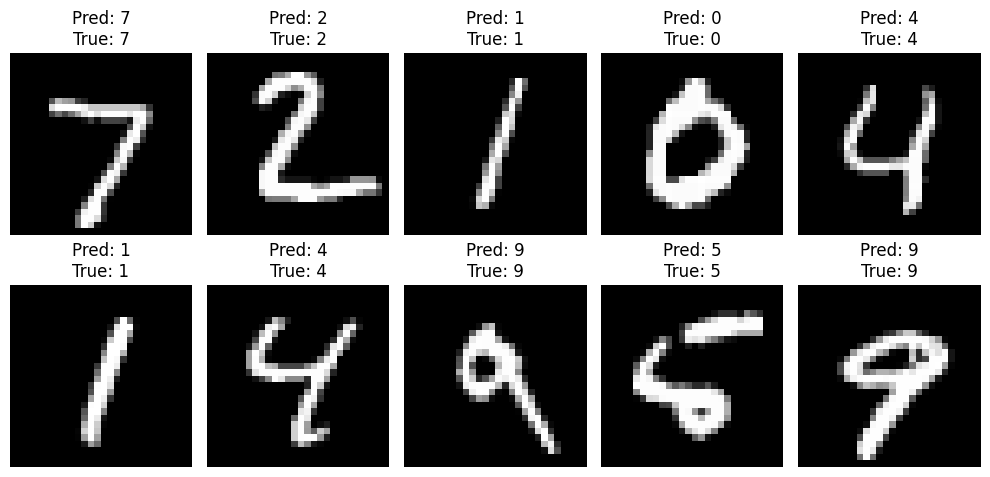

In [ ]:
model.eval()

images, labels = next(iter(test_loader))

with torch.no_grad():
    outputs = model(images)
    predictions = outputs.argmax(dim=1)

# Plot first 10 images
fig, axes = plt.subplots(2, 5, figsize=(10, 5))

for i, ax in enumerate(axes.flat):
    ax.imshow(images[i].squeeze(), cmap="gray")
    ax.set_title(
        f"Pred: {predictions[i].item()}\nTrue: {labels[i].item()}"
    )
    ax.axis("off")

plt.tight_layout()
plt.show()

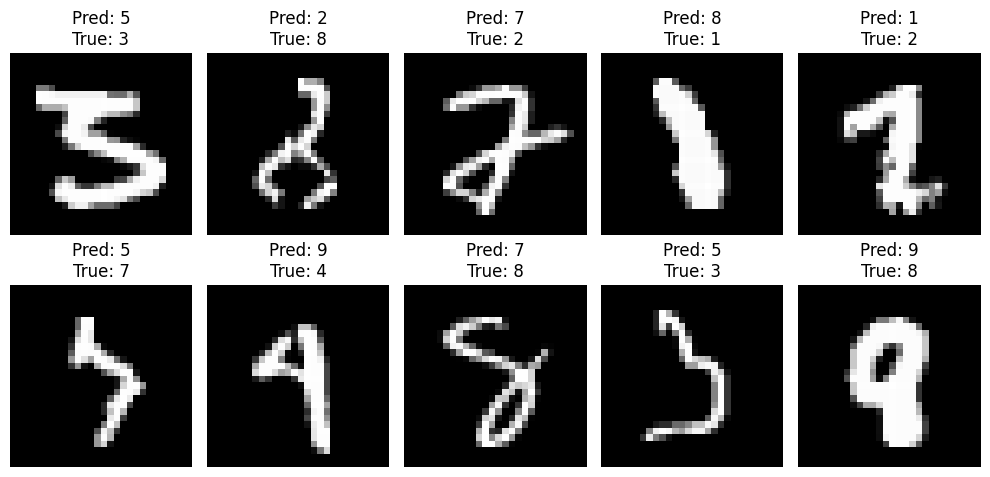

In [ ]:
import matplotlib.pyplot as plt
import torch

model.eval()

wrong_images = []
wrong_labels = []
wrong_predictions = []

with torch.no_grad():
    for images, labels in test_loader:

        outputs = model(images)
        predictions = outputs.argmax(dim=1)

        wrong_mask = predictions != labels

        wrong_images.extend(images[wrong_mask])
        wrong_labels.extend(labels[wrong_mask])
        wrong_predictions.extend(predictions[wrong_mask])

# Plot first 10 wrong predictions
fig, axes = plt.subplots(2, 5, figsize=(10, 5))

for i, ax in enumerate(axes.flat):

    ax.imshow(wrong_images[i].squeeze(), cmap="gray")

    ax.set_title(
        f"Pred: {wrong_predictions[i].item()}\n"
        f"True: {wrong_labels[i].item()}"
    )

    ax.axis("off")

plt.tight_layout()
plt.show()